# Energy-Based Exploration of AION-1 Embeddings

This notebook offers some insights into the way AION-1 galaxy image embeddings correspond to physical parameters.

In this notebook, and energy-base model is constructed whose energy function is of the form 

$$\sum a_{i}E_{i}(emb_{AION-1}, x_{i})$$

where $x_{i}$ is a parameter corresponding to a property of the galaxy and $a_{i}$ is a learned coefficient.  Each energy network is independent of one another and the learned parameter $a_{i}$ indicates how much that feature contributes to the energy.  The input projections of the AION-1 embeddings likewise highlight the components of the AION-1 features are most useful in determining the association between the embedding and a parameter.

In [1]:
import math
import random
import torch
import numpy as np
import torch.nn.functional as F
from torch import nn
from tqdm.notebook import tqdm
import pandas as pd
import copy
import matplotlib.pyplot as plt

In [2]:
class ContinuousSampling:

    SAMPLING_TYPE = 'continuous'

    def __init__(self, vector_length, sampler=None):

        self.vector_length = vector_length
        self.sampler = sampler

    def initialize(self, sample_size, num_new_samples=1):

        if self.sampler is None:
            return [torch.rand((num_new_samples, self.vector_length)) for _ in range(sample_size)]
        else:
            return [self.sampler((num_new_samples, self.vector_length)) for _ in range(sample_size)]

class EmbeddingSampling:

    SAMPLING_TYPE = 'embedding'

    def __init__(self, num_embeddings, weights=None):

        self.num_embeddings = num_embeddings
        self.weights = weights

    def initialize(self, sample_size, num_new_samples=1):

        if self.weights is not None:
            return [torch.from_numpy(np.random.choice(self.num_embeddings, size=(num_new_samples,), dtype=np.int64, p=self.weights)) for _ in range(sample_size)]

        return [torch.randint(0, self.num_embeddings, (num_new_samples,), dtype=torch.long) for _ in range(sample_size)]

class CustomSampler:
    '''Sample from joint distribution over a discrete plus continuous variable
    assumes model has a class_embedding layer with that name
    '''

    def __init__(self, model, *samplers, sample_size=512, max_len=8192):
        """
        Inputs:
            model - Neural network to use for modeling E_theta
            latent_dim - Shape of the latent dim
            num_classes - Number of unique class labels
            sample_size - Batch size of the samples
            max_len - Maximum number of data points to keep in the buffer
        """
        super().__init__()
        self.model = model
        self.samplers = samplers
        self.sample_size = sample_size
        self.max_len = max_len
        self.softmax = nn.Softmax(-1)
        self.log_softmax = nn.LogSoftmax(-1)
        self.example_samples = [sampler.initialize(sample_size) for sampler in self.samplers]

    def sample_new_exmps(self, steps=60, step_size=0.1, device=None, temperature=1.0, **energy_kwargs):
        """
        Function for getting a new batch of "fake" images.
        Inputs:
            steps - Number of iterations in the MCMC algorithm
            step_size - Learning rate nu in the algorithm above
        """
        # Choose 95% of the batch from the buffer, 5% generate from scratch
        n_new = min(np.random.binomial(self.sample_size, 0.05), 1)
        rand_samples = [sampler.initialize(1, n_new)[0] for sampler in self.samplers]

        old_samples = [torch.cat(random.choices(example_samples, k=self.sample_size-n_new), dim=0) for example_samples in self.example_samples]

        input_samples = [torch.cat([rand_sample, old_sample], dim=0).detach().to(device) for rand_sample, old_sample in zip(rand_samples, old_samples)]

        # Perform MCMC sampling
        # This will be len(input_samples)
        input_samples = self.generate_samples(*input_samples, steps=steps, step_size=step_size, temperature=temperature, **energy_kwargs)

        return input_samples

 
    def generate_samples(self, *input_samples, steps=60, step_size=0.1, return_per_step=False, device=None, temperature=1.0, **energy_kwargs):
        """
        Function for sampling images for a given model.
        Inputs:
            model - Neural network to use for modeling E_theta
            inp_latent - latent variables to start from for sampling. If you want to generate new images, enter noise between -1 and 1.
            steps - Number of iterations in the MCMC algorithm.
            step_size - Learning rate nu in the algorithm above
            return_per_step - If True, we return the sample at every iteration of the MCMC
        """
        # Before MCMC: set model parameters to "required_grad=False"
        # because we are only interested in the gradients of the input.
        is_training = self.model.training
        self.model.eval()
        previously_had_grad = {}
        for name, p in self.model.named_parameters():
            previously_had_grad[name] = p.requires_grad
            p.requires_grad = False
        for input_sample, sampler in zip(input_samples, self.samplers):
            if sampler.SAMPLING_TYPE == 'continuous':
                input_sample.requires_grad = True
        #inp_classes.requires_grad = True

        # Enable gradient calculation if not already the case
        had_gradients_enabled = torch.is_grad_enabled()
        torch.set_grad_enabled(True)

        # We use a buffer tensor in which we generate noise each loop iteration.
        # More efficient than creating a new tensor every iteration.

        # List for storing generations at each step (for later analysis)
        outputs_per_step = [[] for _ in range(len(input_samples))]

        # Loop over K (steps)
        for _ in range(steps): # NOTE: Step size is 2*tau

            for sampler, input_sample in zip(self.samplers, input_samples):
                if sampler.SAMPLING_TYPE == 'continuous':
                    noise = torch.randn(input_sample.shape, device=input_sample.device)
                    input_sample.data.add_(noise.data*math.sqrt(step_size))

                    out_latent = -self.model(*input_samples, **energy_kwargs) / temperature
                    out_latent.sum().backward()
                    input_sample.data.add_(-0.5*step_size*input_sample.grad.data)
                    input_sample.grad.detach_()
                    input_sample.grad.zero_()

                elif sampler.SAMPLING_TYPE == 'embedding':

                    batch_size, *_ = input_sample.shape
                    trials = []
                    for class_idx in range(sampler.num_embeddings):
                        input_sample.data[:] = class_idx
                        energy = self.model(*input_samples, **energy_kwargs).sum(-1)
                        trials.append(energy)
                    probs = F.softmax(torch.stack(trials, dim=-1), dim=-1)
                    input_sample.data = torch.multinomial(probs, 1).squeeze(1)

                if return_per_step:
                    for output, input_sample in zip(outputs_per_step, input_samples):
                        output.append(input_sample.clone().detach())


        # Reactivate gradients for parameters for training
        for name, p in self.model.named_parameters():
            p.requires_grad = previously_had_grad[name]
        self.model.train(is_training)

        # Reset gradient calculation to setting before this function
        torch.set_grad_enabled(had_gradients_enabled)

        if return_per_step:
            return [torch.stack(sample, dim=0) for sample in outputs_per_step]
        else:
            return input_samples


# Energy Model

A collection of various energy models that are designed with different levels of configurability.  The `LagrangianEBMFromSamplers` is the one we will use, named such as the output projections act as Lagrange multipliers on the energy components.

In [3]:
class EBM(nn.Module):

    def __init__(self, embedding_dim, feature_dim, hidden_dim, activation=nn.GELU):

        super().__init__()

        self.embedding_dim = embedding_dim
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim

        self.nn = nn.Sequential(
            nn.Linear(embedding_dim+feature_dim, hidden_dim),
            activation(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embedding, features):

        return self.nn(torch.cat([embedding, features], dim=-1))

class EBMWrapper(nn.Module):

    def __init__(self, ebm):

        super().__init__()
        self.ebm = ebm

    def forward(self, *features, embedding=None):

        return self.ebm(embedding, *features)

class EBMFromSamplers(nn.Module):

    def __init__(self, embedding_dim, *samplers, hidden_dim=256, activation=nn.GELU):

        super().__init__()

        self.embedding_dim = embedding_dim
        self.feature_dim = 0
        self.embeddings = []
        self.samplers = samplers
        for sampler in samplers:
            if str(type(sampler)) == str(type(ContinuousSampling(1))):
                self.feature_dim += sampler.vector_length
                self.embeddings.append(nn.Identity())
            elif str(type(sampler)) == str(type(EmbeddingSampling(1))):
                self.feature_dim += sampler.num_embeddings
                self.embeddings.append(nn.Embedding(sampler.num_embeddings, sampler.num_embeddings))
            else:
                print(samplers)
                print(sampler)
                print(isinstance(sampler, EmbeddingSampling))
                print(isinstance(sampler, ContinuousSampling))
                print(type(sampler))
                raise ValueError('NO')
        self.embeddings = nn.ModuleList(self.embeddings)
        self.hidden_dim = hidden_dim

        self.nn = nn.Sequential(
            nn.Linear(embedding_dim+self.feature_dim, hidden_dim),
            activation(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embedding, *features):

        #filtered_features = [torch.where(torch.isnan(feature), torch.zeros_like(feature), feature) for feature in features]
        if len(embedding.shape) > 2:
            filtered_features = [torch.where(torch.isnan(feature), torch.stack(sampler.initialize(feature.shape[0], feature.shape[1])).to(feature), feature) for feature, sampler in zip(features, self.samplers)]
        else:
            filtered_features = [torch.where(torch.isnan(feature), sampler.initialize(1, feature.shape[0])[0].to(feature), feature) for feature, sampler in zip(features, self.samplers)]
        
        embedded_features = [embedding_module(feature) for feature, embedding_module in zip(filtered_features, self.embeddings)]
        return self.nn(torch.cat([embedding, *embedded_features], dim=-1))


class LagrangianEBMFromSamplers(nn.Module):

    def __init__(self, embedding_dim, *samplers, hidden_dim=256, activation=nn.GELU):

        super().__init__()

        self.embedding_dim = embedding_dim
        self.feature_dim = 0
        self.embeddings = []
        self.projections = []
        self.num_projections = 0
        self.samplers = samplers
        for sampler in samplers:
            if str(type(sampler)) == str(type(ContinuousSampling(1))):
                self.feature_dim += sampler.vector_length
                #self.embeddings.append(nn.Identity())
                self.embeddings.append(nn.Conv1d(sampler.vector_length, hidden_dim*sampler.vector_length, kernel_size=1, groups=sampler.vector_length))
                self.num_projections += sampler.vector_length
            elif str(type(sampler)) == str(type(EmbeddingSampling(1))):
                self.feature_dim += hidden_dim
                self.embeddings.append(nn.Embedding(sampler.num_embeddings, hidden_dim))
                self.num_projections += 1
            else:
                print(samplers)
                print(sampler)
                print(isinstance(sampler, EmbeddingSampling))
                print(isinstance(sampler, ContinuousSampling))
                print(type(sampler))
                raise ValueError('Invalid Sampler')
        self.embeddings = nn.ModuleList(self.embeddings)
        self.hidden_dim = hidden_dim
        self.embed_proj = nn.Linear(embedding_dim, hidden_dim*self.num_projections)

        self.nns = nn.Sequential(
            nn.Conv1d(hidden_dim*self.num_projections, hidden_dim*self.num_projections, kernel_size=1, groups=self.num_projections),
            activation(),
            #nn.LayerNorm(hidden_dim),
            nn.Conv1d(hidden_dim*self.num_projections, hidden_dim*self.num_projections, kernel_size=1, groups=self.num_projections),
            activation(),
            nn.Conv1d(hidden_dim*self.num_projections, self.num_projections, kernel_size=1, groups=self.num_projections),
            nn.Sigmoid(),
        ) 

        self.lambda_out = nn.Linear(self.num_projections, 1, bias=False)
        self.softplus = nn.Softplus()

    def forward(self, embedding, *features):

        #filtered_features = [torch.where(torch.isnan(feature), torch.zeros_like(feature), feature) for feature in features]
        if len(embedding.shape) > 2:
            masks = [torch.where(~torch.isnan(feature) for feature in features)] # N_features x dim_features
            #filtered_features = [torch.where(torch.isnan(feature), torch.stack(sampler.initialize(feature.shape[0], feature.shape[1])).to(feature), feature) for feature, sampler in zip(features, self.samplers)]
            filtered_features = [torch.where(torch.isnan(feature), torch.zeros_like(feature), feature) for feature, sampler in zip(features, self.samplers)]

        else:
            masks = [~torch.isnan(feature) for feature in features]
            #filtered_features = [torch.where(torch.isnan(feature), sampler.initialize(1, feature.shape[0])[0].to(feature), feature) for feature, sampler in zip(features, self.samplers)]
            filtered_features = [torch.where(torch.isnan(feature), torch.zeros_like(feature), feature) for feature, sampler in zip(features, self.samplers)]

        embedded_features = [embedding_module(feature[..., None]) for feature, embedding_module in zip(filtered_features, self.embeddings)]
        embedded_features = torch.cat(embedded_features, dim=-1)#.squeeze(-1)#.chunk(self.num_projections, dim=-1)
        emb = self.embed_proj(embedding)[..., None]#.chunk(self.num_projections, dim=-1)
        #emb = torch.stack(emb, dim=-1)[..., None]
        #embedded_features = torch.stack(embedded_features, dim=-1)[..., None]
        comps = (self.nns(embedded_features + emb)*torch.stack(masks, dim=-1)).squeeze(-1)
        #out = self.lambda_out(comps)
        out = F.linear(comps, self.softplus(self.lambda_out.weight))
        #out = self.lambda_out(torch.cat([nn(e+f)*m[...,None] for (nn, e, f, m) in zip(self.nns, embedded_features, emb, masks[0].unbind(-1))], dim=-1))
        return out




# Preprocessing

The following just sets up some automatic preprocessors based on the data requested in a pandas dataframe.  In this block is where you can set your local paths.

In [4]:
class LogPreProcessor:


    def transform(self, x):

        return np.log(x)

    def inverse_transform(self, x):

        return np.exp(x)


class ScalarPreProcessor:

    def __init__(self, offset, scale):

        self.offset = offset
        self.scale = scale

    def transform(self, x):

        return (x - self.offset) / self.scale

    def inverse_transform(self, x):

        return x * self.scale + self.offset

class MinMaxPreProcessor(ScalarPreProcessor):

    def __init__(self, minimum, maximum):

        offset = minimum
        scale = maximum - minimum
        super().__init__(offset, scale)

class CategoricalPreprocessor:

    def __init__(self, labels):
        
        self.n_labels = len(labels)
        self.labels = labels
        self.label_to_index = dict(zip(labels, range(self.n_labels)))
        self.index_to_label = dict(zip(self.label_to_index.values(), self.label_to_index.keys()))

    def transform(self, x):

        out = []
        for x_ in x:
            out.append(self.label_to_index[x_])
        return out

    def inverse_transform(self, x):
        out = []
        for x_ in x:
            out.append(self.index_to_label[x_])
        return out
        

class ChainPreProcessor:

    def __init__(self, *preprocessors):

        self.preprocessors = preprocessors

    def transform(self, x):

        for preprocessor in self.preprocessors:
            x = preprocessor.transform(x)
        return x

    def inverse_transform(self, x):

        for preprocessor in self.preprocessors[::-1]:
            x = preprocessor.inverse_transform(x)
        return x




def extract_parameters_by_kind(dataframe):

    kinds = {}
    support = {}
    for column in dataframe.columns:
        dtype = dataframe[column].dtype
        if dtype is np.dtype('int64'):
            continue
        elif dtype is np.dtype('float64'):
            dtype = np.dtype('float32')
        if dtype not in kinds:
            kinds[dtype] = []
        if dtype is np.dtype('float32'):
            support[column] = np.array([dataframe[column].values.min(), dataframe[column].values.max()])
        elif dtype is np.dtype('O'):
            if len(dataframe[column].unique()) in (1, len(dataframe)):
                continue
            #unique_values = [value for value in dataframe[column].unique() if value is not None]
            support[column] = {'N':len(dataframe[column].unique()), "values":dataframe[column].unique()}
        elif dtype is np.dtype('bool'):
            support[column] = 'bool'
        kinds[dtype].append(column)

    return kinds, support

def get_samplers(kinds, support):
    '''return sampler objects and names'''

    samplers = []
    sampler_names = []
    names = []
    for dtype in kinds:
        for name in kinds[dtype]:
            names.append(name)
        if dtype is np.dtype('float32'):
            samplers.append(ContinuousSampling(len(kinds[dtype])))
            sampler_names.append(kinds[dtype])
        elif dtype is np.dtype('O'):
            for name in kinds[dtype]:
                samplers.append(EmbeddingSampling(support[name]["N"]))
                sampler_names.append([name])
        elif dtype is np.dtype('bool'):
            for name in kinds[dtype]:
                samplers.append(EmbeddingSampling(2))
                sampler_names.append([name])

    return samplers, names, sampler_names

def get_preprocessors(kinds, support):
    '''return sampler objects and names'''
    preprocessors = {}
    for dtype in kinds:
        for name in kinds[dtype]:
            if dtype is np.dtype('float32'):
                if support[name][0] > 0.0:
                    minimum = np.log(support[name][0])
                    maximum = np.log(support[name][1])
                    preprocessors[name] = ChainPreProcessor(LogPreProcessor(), MinMaxPreProcessor(minimum, maximum))
                else:
                    preprocessors[name] = MinMaxPreProcessor(*support[name])
            elif dtype is np.dtype('O'):
                preprocessors[name] = CategoricalPreprocessor(support[name]["values"])
            elif dtype is np.dtype('bool'):
                preprocessors[name] = CategoricalPreprocessor([True, False])
                
    return preprocessors

def preprocess_dataframe(dataframe, preprocessors, kinds, device='mps'):

    tensors = []
    for dtype in kinds:
        if dtype is np.dtype('float32'):
            sub_tensors = []
            for name in kinds[dtype]:
                data = dataframe[name].values
                
                data = np.array(preprocessors[name].transform(data))
                if data.dtype is np.dtype('float64'):
                    data = data.astype(np.float32)
                sub_tensors.append(torch.from_numpy(data).to(device))
            tensors.append(torch.stack(sub_tensors, dim=-1))
        else:
            for name in kinds[dtype]:
                data = dataframe[name].values
                data = np.array(preprocessors[name].transform(data))
                tensors.append(torch.from_numpy(data).to(device))

    return tensors

def prostprocess_tensors(tensors, preprocessors, sampler_names, device='mps'):

    new_tensors = []
    for tensor, names in zip(tensors, sampler_names):
        if len(name) > 1:
            sub_tensors = []
            for name, sub_tensor in zip(names, tensor):
                data = sub_tensor.detach().cpu().numpy()
                
                data = np.array(preprocessors[name].inverse_transform(data))
                sub_tensors.append(data)
            new_tensors.append(np.stack(sub_tensors, axis=-1))
        else:
            name = names[0]
            data = tensor.detach().cpu().numpy()
            data = np.array(preprocessors[name].inverse_transform(data))
            new_tensors.append(data)

    return new_tensors


device = 'mps'
batch_size=256

parameters_obs = pd.read_parquet("/Users/jackob/Downloads/KAAI-2026-Hackathon/observational-data/anchor.parquet")
drop_parameters = [
    "ra", 
    "dec", 
    "specZ", 
    "nsaRedshift", 
    "zouPhotoZ", 
    "zouPhotoZerr", 
    "nobsG",
    "nobsR",
    "nobsI",
    "nobsZ",
    "vdispValid",
    "bptValid",
    "shapeDefined",
    "morphReliable",
    'votesSmoothOrFeatured',
    'votesDiskEdgeOn',
    'votesBar',
    'votesHasSpiralArms',
    'votesSpiralWinding',
    'votesSpiralArmCount',
    'votesBulgeSize',
    'votesHowRounded',
    'votesEdgeOnBulge',
    'votesMerging',

    'type',
    'bptClass',
    'fsSpectype',
]
parameters_obs = parameters_obs.drop(drop_parameters, axis=1)

keep_parameters = [
  #'type',
  #'bptClass',
  #'fsSpectype',
  'redshift',
  'redshiftErr',
  'logMstar',
  'logMform',
  'logMformErr',
  'avgSfr',
  'tageMw',
  'zMw'
]
parameters_obs = parameters_obs[keep_parameters]
#parameters_obs = parameters_obs.iloc[:, :9]

kinds, support = extract_parameters_by_kind(parameters_obs)
samplers, names, sampler_names = get_samplers(kinds, support)
preprocessors = get_preprocessors(kinds, support)

preprocessors, support, kinds, samplers, sampler_names

tensors = preprocess_dataframe(parameters_obs, preprocessors, kinds)
tensors
embeddings = np.load("/Users/jackob/Downloads/KAAI-2026-Hackathon/observational-data/anchorEImg.npy")
embedding_tensors_raw = torch.from_numpy(embeddings).to(torch.float32).to(device)

embedding_tensors_mean = embedding_tensors_raw.mean(dim=0, keepdim=True)
embedding_tensors_std = embedding_tensors_raw.std(dim=0, keepdim=True)
embedding_tensors = (embedding_tensors_raw - embedding_tensors_mean)/embedding_tensors_std

dataset = torch.utils.data.TensorDataset(embedding_tensors, *tensors)

# Setup the data loaders

In [6]:
frac_train = 0.8
frac_val = 0.1

num_train = int(len(dataset)*frac_train)
num_val = int(len(dataset)*frac_val)
num_test = int(len(dataset) - num_train - num_val)

train_data, val_data, test_data = torch.utils.data.random_split(dataset, (num_train, num_val, num_test))

In [7]:
batch_size=256
train_dataloader = torch.utils.data.DataLoader(train_data, 
                                               batch_size=batch_size,
                                               shuffle=True,
                                               drop_last=True,
                                               num_workers=0,
                                              )
val_dataloader = torch.utils.data.DataLoader(val_data, 
                                             batch_size=batch_size,
                                               shuffle=False,
                                               drop_last=True,
                                               num_workers=0,
                                              )
test_dataloader = torch.utils.data.DataLoader(test_data, 
                                              batch_size=batch_size,
                                               shuffle=False,
                                               drop_last=True,
                                               num_workers=0,
                                              )

In [16]:
num_epochs = 50

# Initialize the model and optimizer

In [40]:


#model = EBM(embedding_tensors.shape[1], parameter_tensors.shape[1], 32).to(device)
model = LagrangianEBMFromSamplers(embedding_tensors.shape[1], *samplers, hidden_dim=16).to(device)
embedding_sampler = ContinuousSampling(embedding_tensors.shape[1])
sampler = CustomSampler(model, embedding_sampler, *samplers, sample_size=batch_size)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4, decoupled_weight_decay=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs*len(train_dataloader), eta_min=1e-8)

train_loss_epoch = []
train_loss = []
val_loss_epoch = []
val_loss = []

In [41]:
energy_norm = 0.01
num_steps=60 #(1024+12)*2
#num_steps = 100
step_size=1/num_steps

print('Num Steps:', num_steps)
print('Step Size:', step_size)

def get_loss(input_embedding, input_features, sampler):

    fake_input = sampler.sample_new_exmps(device=device, steps=num_steps, step_size=step_size)
    real_input = (input_embedding, *input_features)

    real_out = model(*real_input)
    fake_out = model(*fake_input)

    reg_loss = energy_norm * (real_out ** 2 + fake_out ** 2).mean()
    cdiv_loss = (fake_out - real_out).mean()
    total_loss = reg_loss + cdiv_loss
    
    return total_loss, cdiv_loss

#@torch.compile
def train_step(input_embedding, input_features, sampler, optimizer):

    optimizer.zero_grad(set_to_none=True)
    total_loss, cdiv_loss = get_loss(input_embedding, input_features, sampler)
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    return total_loss, cdiv_loss






Num Steps: 60
Step Size: 0.016666666666666666


# Train the model

In [ ]:
best_val = np.inf
best_epoch = 0

for epoch in (pbar_epoch := tqdm(range(num_epochs*5), desc='epoch')):
    model.train()
    train_loss_epoch = []
    for embedding, *features in (pbar:=tqdm(train_dataloader, leave=False, desc='Train')):
        total_loss, cdiv_loss = train_step(embedding, features, sampler, optimizer)
        pbar.set_postfix(loss=f"{total_loss.item():<9.2e}", cdiv=f"{cdiv_loss.item():<9.2e}", lr=f"{scheduler.get_last_lr()[0]:<9.2e}")
        train_loss_epoch.append(total_loss.item())
    train_loss.append(np.mean(train_loss_epoch))
    

    model.eval()
    val_loss_epoch = []
    #with torch.inference_mode():
    for embedding, *features in (pbar:=tqdm(val_dataloader, leave=False, desc='Validate')):
        total_loss, cdiv_loss = get_loss(embedding, features, sampler)
        pbar.set_postfix(val_loss=f"{total_loss.item():<9.2e}", val_cdiv=f"{cdiv_loss.item():<9.2e}")
        val_loss_epoch.append(total_loss.item())
    val_loss.append(np.mean(val_loss_epoch))
    if val_loss[-1] < best_val:
        best_val = val_loss[-1]
        best_epoch = epoch
        state_dict = copy.deepcopy(model.state_dict())

    pbar_epoch.set_postfix(train_loss=f"{train_loss[-1]:<9.2e}", val_loss=f"{val_loss[-1]:<9.2e}", best=f"{best_epoch}:{best_val:<9.2e}")
        

epoch:   0%|          | 0/250 [00:00<?, ?it/s]

Train:   0%|          | 0/31 [00:00<?, ?it/s]

Validate:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/31 [00:00<?, ?it/s]

Validate:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train:   0%|          | 0/31 [00:00<?, ?it/s]

Validate:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/31 [00:00<?, ?it/s]

Validate:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/31 [00:00<?, ?it/s]

# Load back up the best validation loss

In [ ]:
model.load_state_dict(state_dict)

# And plot it

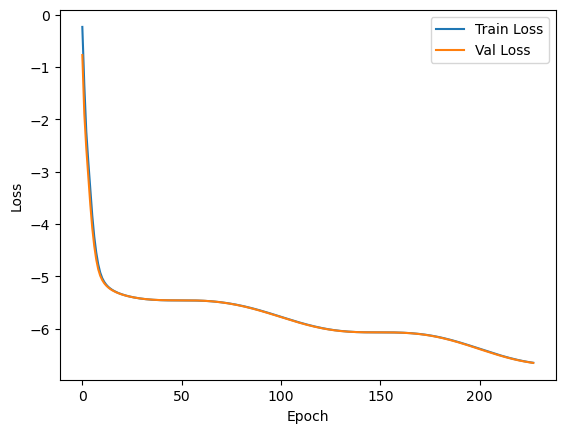

In [30]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

new_embedding.shape
model(new_embedding[None,...].expand(new_samples[0].shape[0], -1, -1), *new_samples)

# Generate some sample chains from the energy model over a batch of test AION-1 embeddings

In [31]:


ebm_wrapper = EBMWrapper(model)
new_sampler = CustomSampler(ebm_wrapper, *samplers, sample_size=batch_size)

new_embedding, *new_features = next(iter(test_dataloader))

for name_set in sampler_names:
    if len(name_set) == 1: # implicit embedding sampler
        continue
    columns = name_set
    break
new_samples = new_sampler.generate_samples(*[torch.zeros_like(f) for f in new_features], embedding=new_embedding, device=device, return_per_step=True, steps=200, step_size=step_size)
#new_samples[0] = new_samples[0][n_burn:, :]
energies = []
for i, new_sample in enumerate(zip(*new_samples)):
    energy = ebm_wrapper(*new_sample, embedding=new_embedding)#[None,...].expand(new_samples[0].shape[0], -1, -1))
    energies.append(energy)
energy = torch.stack(energies)

# Run Nested Sampling on an AION-1 Embedding

This cell runs nested sampling with the likelihood being the energy (loglikelihood).  This is mostly a test to check if our energy model recovers parameters, but based on the spreads in the output distributions, we can see how well the AION-1 embeddings associate with the parameters.

In [32]:
import ultranest
from scipy import stats
import time

norm_dist = stats.norm()
def prior_transform(cube):

    return cube

    #return norm_dist.ppf(cube)*parameter_tensors_std.cpu().numpy()+parameter_tensors_mean.cpu().numpy()
num_cat = 0
def likelihood(parameters):
    parameters_tensor = torch.from_numpy(parameters).to(torch.float32).to(device)
    sample_list = [*[f[0].expand(parameters.shape[0]) for f in new_features[:num_cat]], parameters_tensor, *[f[0].expand(parameters.shape[0]) for f in new_features[num_cat+1:]]]
    #print([s.shape for s in sample_list])
    return ebm_wrapper(*sample_list, embedding=new_embedding[0][None, ...].expand(parameters.shape[0], -1)).squeeze(-1).cpu().detach().numpy()

nested_sampler = ultranest.ReactiveNestedSampler(columns, likelihood, transform=prior_transform, vectorized=True)
with torch.inference_mode():
    sampler_results = nested_sampler.run()#viz_callback=ultranest.viz.nicelogger)

print([f[0] for f in new_features])



[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=7  
[ultranest] Likelihood function evaluations: 400
[ultranest]   logZ = 7.165 +- 9.455e-16
[ultranest] Effective samples strategy satisfied (ESS = 400.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 40 minimum live points (dlogz from 0.00 to 0.00, need <0.5)
[ultranest]   logZ error budget: single: inf bs:0.00 tail:0.69 total:0.69 required:<0.50
[ultranest] done iterating.
[tensor([0.7728, 0.6358, 0.8925, 0.8913, 0.3888, 0.7589, 0.9810, 0.6563],
       device='mps:0')]


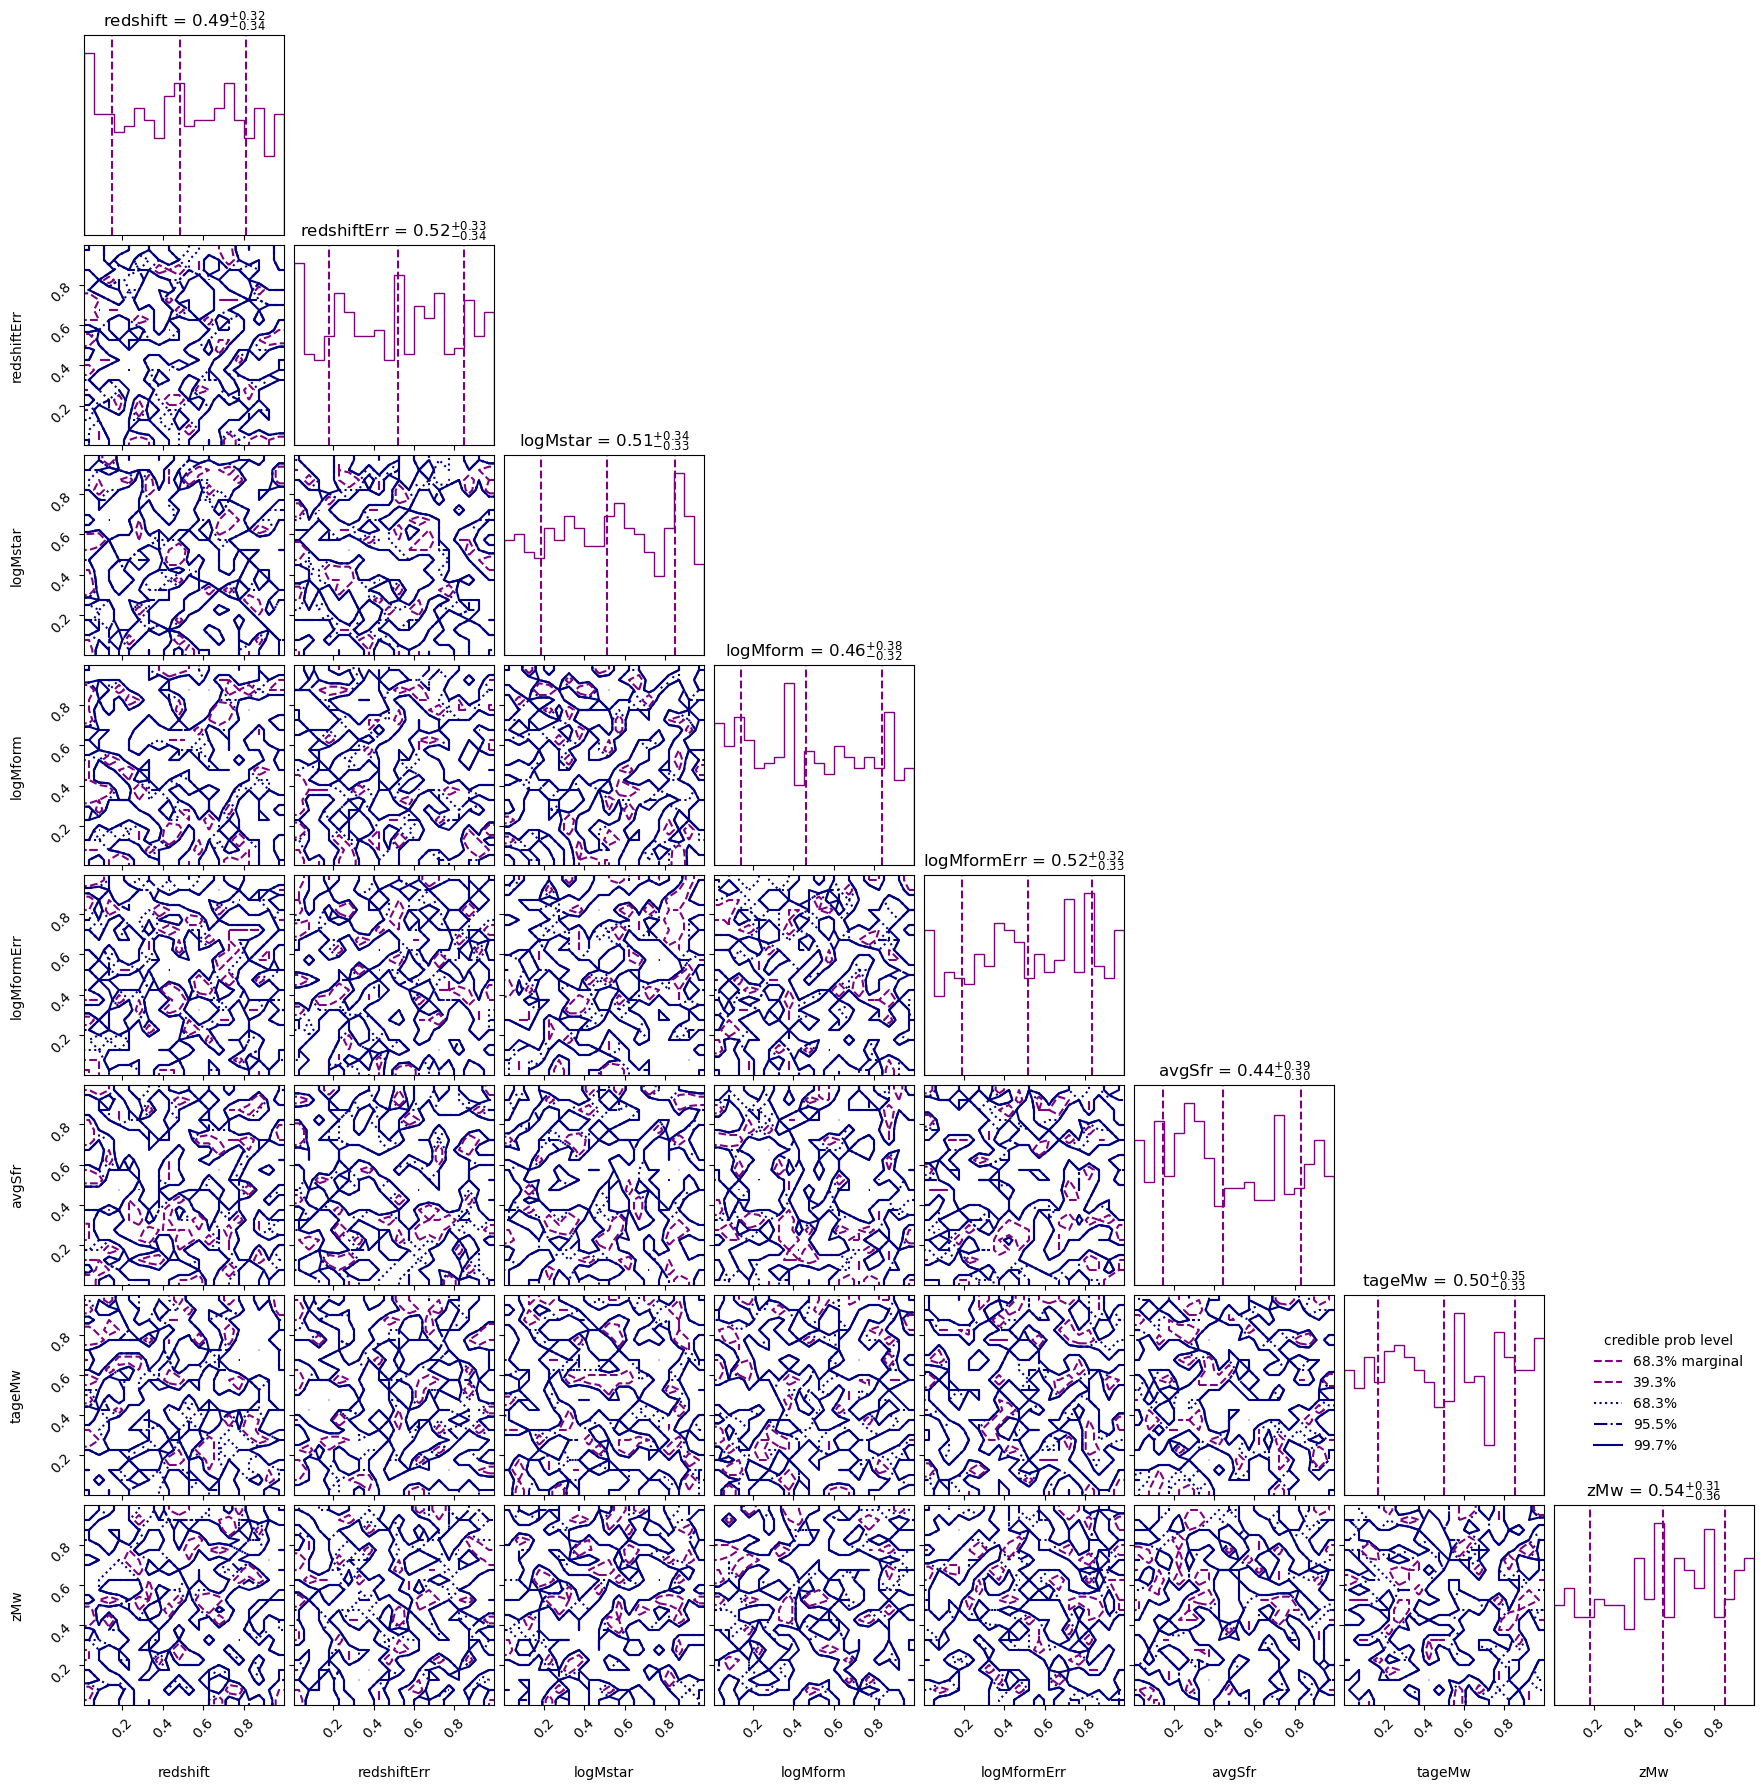

In [33]:
nested_sampler.plot_corner()

# See how close we get

This is in the normalized space, post-processing would be needed to see the true values

In [34]:
print("True | Pred")
for i, j in zip([f[0] for f in new_features][0], sampler_results['maximum_likelihood']['point']):
    print(i.item(), j)

True | Pred
0.7728127837181091 0.8595044432679034
0.6358233094215393 0.9215215012607958
0.8924798369407654 0.27604500680702215
0.8913010358810425 0.6711849752141605
0.3887724280357361 0.16724526877178136
0.758948028087616 0.8500751025449089
0.9810142517089844 0.9521303756573306
0.6563162803649902 0.12677136713658355


# Look at the weight contributions and the input AION-1 projections.  

On the left: Sorted AION-1 projection components from the EMB corresponding to each property.  Acts as a CDF showing the distribution of the relative contribution of each vector in the matrix.  The title shows the output coefficient, $a_{i}$ for weighting the energy component, showing how much that parameter is associated with the embedding relative to the other parameters.

On the right: The input projection matricies corresponding the the parameter shown on the left.

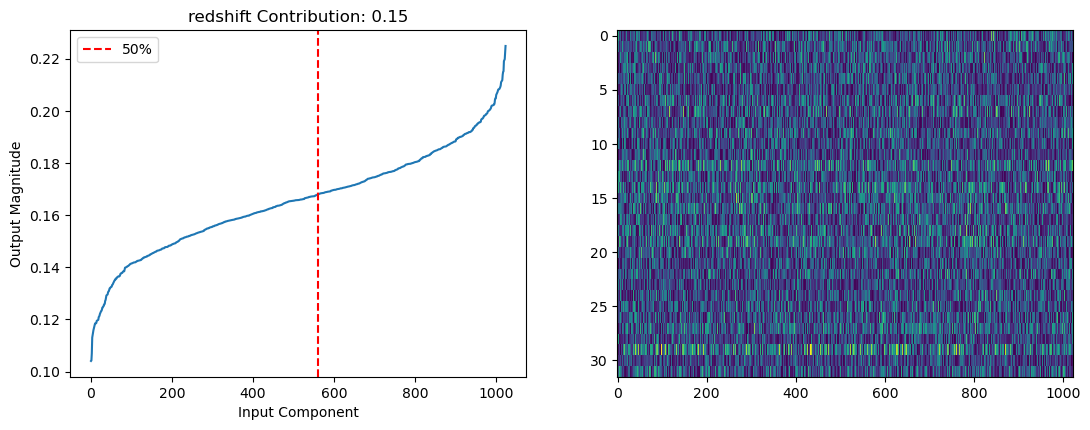

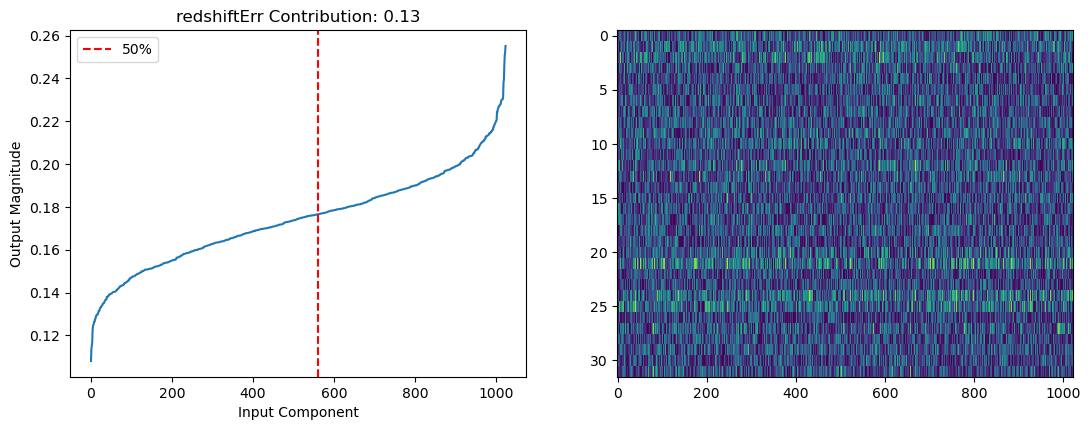

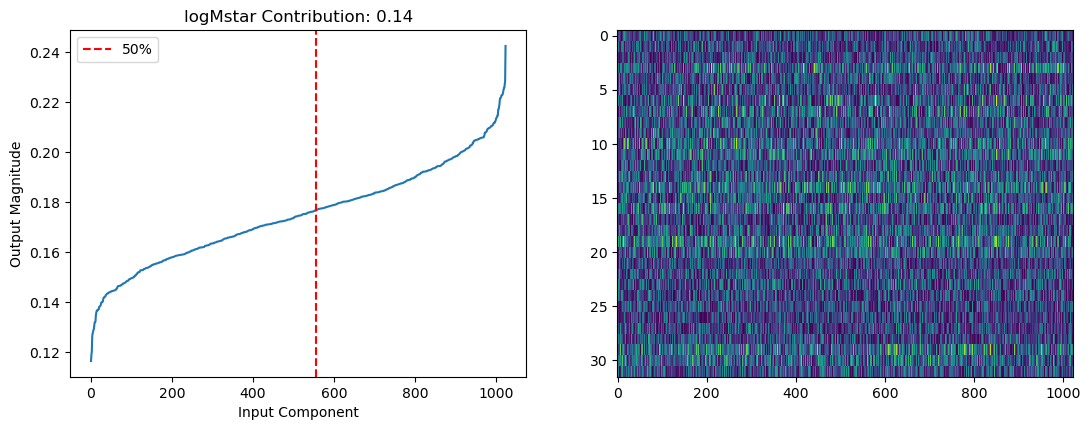

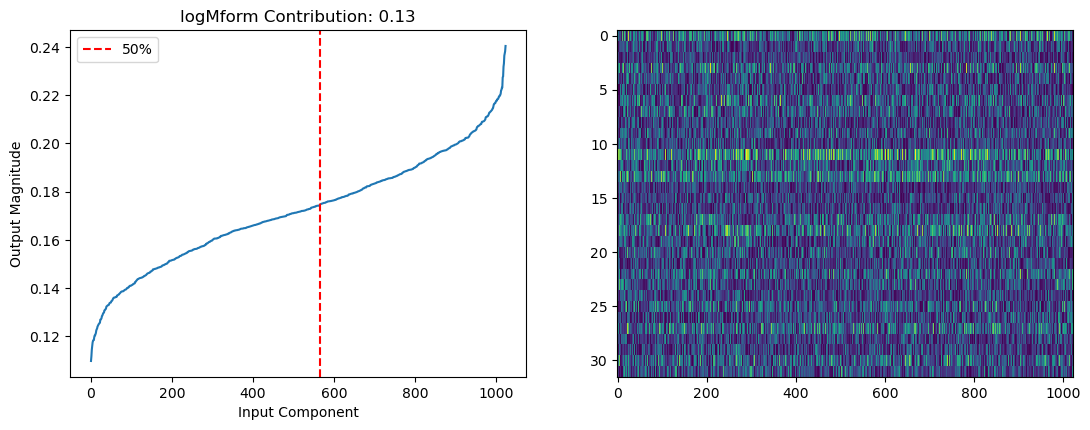

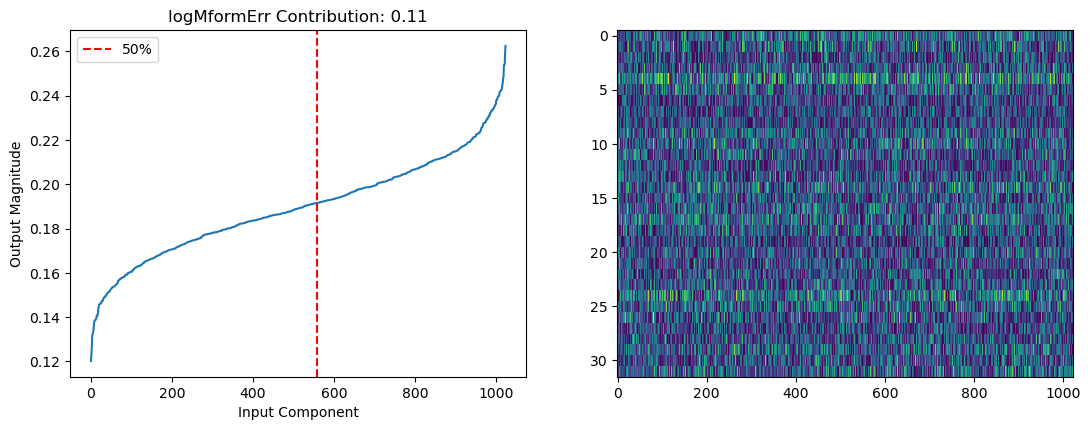

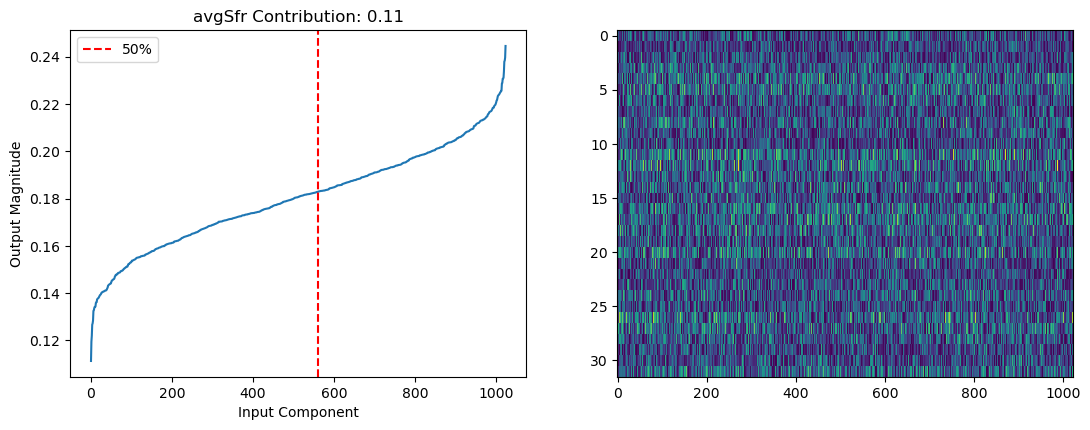

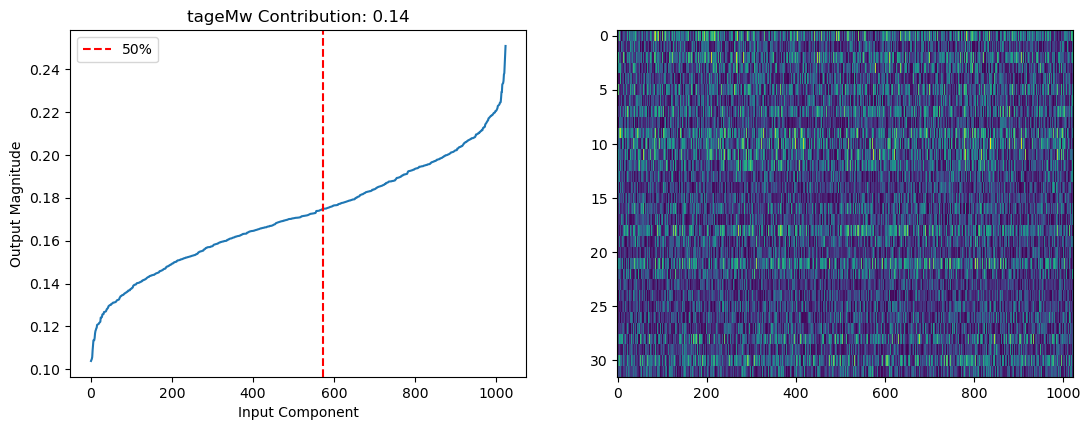

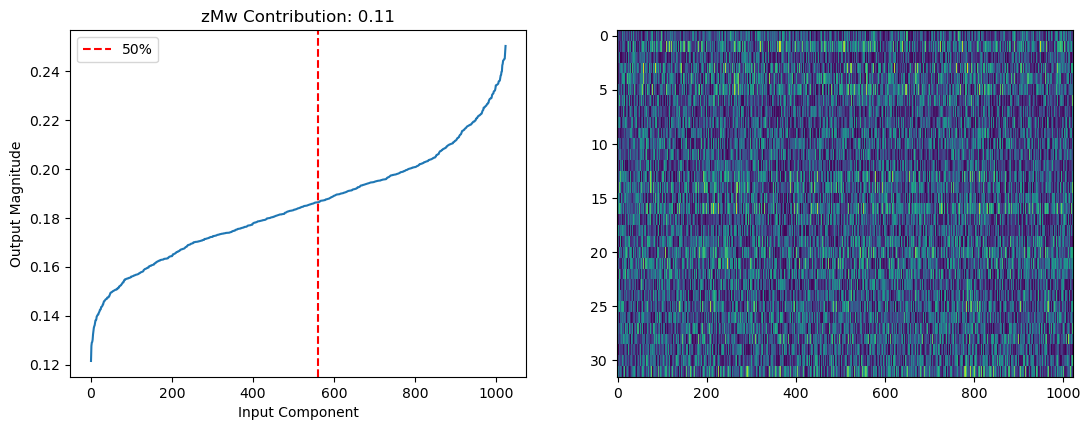

In [38]:

projections = model.embed_proj.weight.chunk(model.num_projections, dim=0)
lambda_projections = (model.softplus(model.lambda_out.weight)/((model.softplus(model.lambda_out.weight)).sum())).chunk(model.num_projections, dim=0)[0][0]

for projection, column, lp in zip(projections, columns, lambda_projections):
    fig, ax = plt.subplots(1,2, figsize=(8*1.618033, 4.5))
    plt.sca(ax[0])
    plt.title(f"{column} Contribution: {lp.item():.2f}")
    #plt.plot(np.sqrt((projection.cpu().detach().numpy()**2).sum(axis=0)))
    proj = np.sqrt((projection.cpu().detach().numpy()**2).sum(axis=0))
    s_proj = sorted(proj)
    plt.plot(s_proj)
    s_cum = np.cumsum(s_proj)/np.sum(s_proj)
    idx = np.argmin((s_cum - 0.5)**2)
    plt.axvline(idx, ls='--', color='r', label='50%')
    plt.xlabel('Input Component')
    plt.ylabel('Output Magnitude')
    plt.legend()
    plt.sca(ax[1])
    plt.imshow(projection.cpu().detach().abs().numpy(), interpolation='None', aspect='auto')

In [ ]:
from scipy.optimize import minimize
from scipy.special import factorial

def estimate_dist_from_moments(dist, N=3):

    funcs = [(lambda x: x**(i+1)) for i in range(N)]
    truths = np.sum(np.array([func(dist) for func in funcs]), axis=1) # len(funcs) averages
    polynomial_func = lambda x, *lambs: np.sum([func(x)*l for func, l in zip(funcs, lambs)], axis=0) # shape x
    partition_func = lambda x, *lambs: np.sum(np.exp(polynomial_func(x, *lambs))) # shape x -> 1
    # d/da exp(ax+bx) = exp(ax+bx)*a
    dz_dlambda = lambda x, *lambs: np.sum([func(x)*np.exp(polynomial_func(x, *lambs)) for func in funcs], axis=1) # shape lambda * x -> lambda

    pdf_cond = lambda x, *lambs: (np.exp(polynomial_func(x, *lambs))/partition_func(x, *lambs)*len(x)/N, print(partition_func(x, *lambs)))[0]
    entropy = lambda x, *lambs: np.sum(-pdf_cond(x, *lambs) * np.log(pdf_cond(x, *lambs)))
    
    target_minimizer = lambda lambs, x: np.sum((dz_dlambda(x, *lambs) - truths)**2)# - entropy(x, *lambs)

    x0 = -1/factorial(np.arange(N)+1)
    result = minimize(target_minimizer, x0=x0, args=(dist,), bounds=[(-1, 1)]*len(x0))

    Z = partition_func(dist, *result.x)

    pdf = lambda x: np.exp(polynomial_func(x, *result.x))/Z/N*len(dist)

    return result, pdf

def get_vector_normal(vector):
    '''vector is shape N'''
    vector = vector[None, :].expand(vector.shape[0], -1)
    U, S, Vh = torch.linalg.svd(vector)
    tol = 1e-5
    null_mask = S <= tol
    null_space = Vh[null_mask].T
    return null_space.squeeze(-1)
    

get_vector_normal(torch.tensor([1.0, 0.0]))

from scipy import stats
norm_dist = stats.norm()
samples = norm_dist.ppf(np.random.random(1000))

result, pdf = estimate_dist_from_moments(samples, 4)

plt.scatter(samples, pdf(samples))
plt.hist(samples, density=True, bins=int(np.sqrt(len(samples))), histtype='step')
print(result)

In [ ]:
nested_sampler.plot_trace()

In [ ]:
type(new_samples)

In [ ]:
features.shape

In [ ]:

for name_set, sampler, samples, features in zip(sampler_names, samplers, new_samples, new_features):
    if len(name_set) == 1: # implicit embedding sampler
        continue
    columns = name_set
    for i, column in enumerate(columns):
    
        fig, axes = plt.subplots(1,2, figsize=(8*1.610833, 4.5))
        plt.sca(axes[0])
        plt.hist(samples[:, 0, i].detach().cpu().numpy(), 
                 label=column, histtype='step', bins=int(np.sqrt(samples.shape[0])), color='k')
        plt.axvline(features[0, i].item(), ls='--', color='r')
    
        best_energy_idx = np.argmax(energy[:, 0, 0].cpu().detach().numpy())
        best_sample = samples[best_energy_idx, 0, i].detach().cpu().numpy()
        plt.axvline(best_sample, color='b', ls='--', label='Max Likelihood')
        
        plt.legend()
        
        #plt.title(f'true {column}={true_parameters[0, i].item():.2f}')
    
        plt.sca(axes[1])
        plt.scatter(np.arange(len(energy)), samples[:, 0, i].detach().cpu().numpy(), c=-energy[:, 0, 0].cpu().detach().numpy(), label=column)
        cbar = plt.colorbar()
        cbar.ax.set_ylabel('Energy')
        plt.axhline(features[0, i].item(), ls='--', color='r')
        plt.legend()
        plt.title('Chains')

In [ ]:
for i, column in enumerate(columns):

    plt.figure()
    plt.hist((new_samples[0][:, :, i].detach().cpu().numpy().ravel() - true_parameters[0, i].item())**2, 
             label=column, histtype='step', bins=int(np.sqrt(corrected_samples[..., i].ravel().shape[0])), color='k')
    plt.axvline(0.0, ls='--', color='r')
    plt.legend()
    
    plt.title(f'Residual Normalized {column} Over All Samples')

In [ ]:

parameters_obs = pd.read_parquet("/Users/jackob/Downloads/KAAI-2026-Hackathon/observational-data/anchor.parquet")
embeddings_obs = np.load("/Users/jackob/Downloads/KAAI-2026-Hackathon/observational-data/anchorEImg.npy")


embedding_tensors_obs_raw = torch.from_numpy(embeddings_obs).to(torch.float32).to(device)
embedding_tensors_obs = (embedding_tensors_obs_raw - embedding_tensors_mean)/embedding_tensors_std



In [ ]:
n_burn = 100

obs_embedding = embedding_tensors_obs
new_sampler.sample_size=len(obs_embedding)
obs_samples = new_sampler.generate_samples(torch.zeros((len(obs_embedding), new_features.shape[1]), device=device).detach(), embedding=obs_embedding, device=device, return_per_step=True, steps=200, step_size=step_size)

obs_samples[0] = obs_samples[0][n_burn:]

In [ ]:
corrected_obs_samples = obs_samples[0] * parameter_tensors_std[None, ...] + parameter_tensors_mean[None, ...]

In [ ]:
for i, column in enumerate(columns):
    parameters_obs[f'pred_{column}'] = corrected_obs_samples[..., i].mean(dim=0).cpu().numpy()
    parameters_obs[f'pred_{column}_err'] = corrected_obs_samples[..., i].std(dim=0).cpu().numpy()

In [ ]:
parameters_obs[['redshift', 'redshiftErr', 'pred_redshift', 'pred_redshift_err']]

In [ ]:
plt.scatter(parameters_obs['redshift'].values, parameters_obs['pred_redshift'].values, s=1)
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Redshift')

In [ ]:
import ultranest
from scipy import stats

norm_dist = stats.norm()
def prior_transform(cube):

    return norm_dist.ppf(cube)*parameter_tensors_std.cpu().numpy()+parameter_tensors_mean.cpu().numpy()

def likelihood(parameters):
    return ebm_wrapper((torch.from_numpy(parameters).to(torch.float32).to(device)-parameter_tensors_mean)/parameter_tensors_std, embedding=obs_embedding[1][None, ...].expand(parameters.shape[0], -1)).squeeze(-1).cpu().detach().numpy()

sampler_obs = ultranest.ReactiveNestedSampler(columns, likelihood, transform=prior_transform, vectorized=True)
sampler_obs.run()

In [ ]:
sampler_obs.plot_corner()

In [ ]:
for c in parameters_obs.columns:
    print(c, parameters_obs[c].values[1])